## **Data Prep**

##### **Imports and Setup**

In [149]:
"""
Importing necessary libraries
"""
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MultiLabelBinarizer
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt



import warnings
warnings.filterwarnings("ignore")

In [150]:
"""
Import the dataset
"""
dataset = pd.read_csv('.\games .csv')

In [151]:
"""
Global parameters
"""
thresholdMissingsValuesColumn = 30
thresholdIndependentDevPub = 5
dropProportionDatsetGlobal = 3


##### **Data understanding**

This part just display some informations to help you understand the composition of the dataset

In [152]:
"""
Display the first few rows of the dataset to see its structure
"""
dataset.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,20200,Galactic Bowling,"Oct 21, 2008",0 - 20000,0,0,19.99,0,0,Galactic Bowling is an exaggerated and stylize...,...,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1,655370,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,...,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
2,1732930,Jolt Project,"Nov 17, 2021",0 - 20000,0,0,4.99,0,0,Jolt Project: The army now has a new robotics ...,...,0,0,0,Campião Games,Campião Games,Single-player,"Action,Adventure,Indie,Strategy",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
3,1355720,Henosis™,"Jul 23, 2020",0 - 20000,0,0,5.99,0,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,...,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
4,1139950,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0,0,0.00,0,0,ABOUT THE GAME Play as a hacker who has arrang...,...,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


In [153]:
"""
Give some exemples of the data types of each column
"""
dataset.dtypes

AppID                           int64
Name                           object
Release date                   object
Estimated owners               object
Peak CCU                        int64
Required age                    int64
Price                         float64
Discount                        int64
 DLC count                      int64
About the game                 object
Supported languages            object
Full audio languages           object
Reviews                        object
Header image                   object
Website                        object
Support url                    object
Support email                  object
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                 object
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements

In [154]:
"""
Get the shape of the dataset (number of rows and columns)
"""
dataset.shape

(111452, 40)

##### **Initial Cleaning**

This part clean all the basics things in the dataset. It's the very begining of the data cleaning

In [155]:
"""
Detect missing values for some columns
"""
dataset.isnull().sum() 

AppID                              0
Name                               6
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
Discount                           0
 DLC count                         0
About the game                  6483
Supported languages                0
Full audio languages               0
Reviews                       100828
Header image                       0
Website                        64994
Support url                    60693
Support email                  19025
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                107447
User score                         0
Positive                           0
Negative                           0
Score rank                    111408
Achievements                       0
R

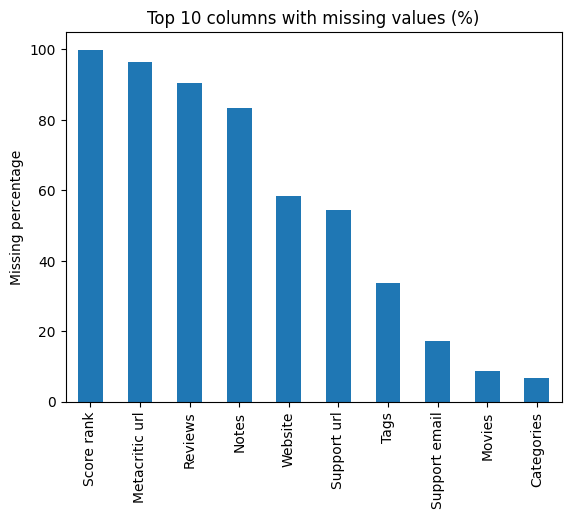

AppID                          0.000000
Name                           0.005383
Release date                   0.000000
Estimated owners               0.000000
Peak CCU                       0.000000
Required age                   0.000000
Price                          0.000000
Discount                       0.000000
 DLC count                     0.000000
About the game                 5.816854
Supported languages            0.000000
Full audio languages           0.000000
Reviews                       90.467645
Header image                   0.000000
Website                       58.315687
Support url                   54.456627
Support email                 17.070129
Windows                        0.000000
Mac                            0.000000
Linux                          0.000000
Metacritic score               0.000000
Metacritic url                96.406525
User score                     0.000000
Positive                       0.000000
Negative                       0.000000


In [156]:
"""
Detect missing value percentages for each column
"""
missing_percentage = 100 * dataset.isnull().sum() / len(dataset)
missing_percentage.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 columns with missing values (%)")
plt.ylabel("Missing percentage")
plt.show()
print(missing_percentage)

In [157]:
"""
Drop columns with more than 30% missing values
"""
# Create a copy of the original dataset where we will drop columns with more than 30% missing values
lessColumns_dataset = dataset.copy()

# Identify columns with more than 30% missing values
cols_to_drop = missing_percentage[missing_percentage > thresholdMissingsValuesColumn]
print("Columns with more than 30% of missing values :")
print(cols_to_drop)

# Drop columns with more than 30% missing values
lessColumns_dataset.drop(columns=cols_to_drop.index, inplace=True)

Columns with more than 30% of missing values :
Reviews           90.467645
Website           58.315687
Support url       54.456627
Metacritic url    96.406525
Score rank        99.960521
Notes             83.446686
Tags              33.577684
dtype: float64


In [158]:
"""
Drop some columns that are not useful for our analysis
"""
lessColumns_dataset.drop(columns=['AppID', 'Release date', 'Name', 'Movies', 'Screenshots', 'Median playtime two weeks', 'Average playtime two weeks', 'User score', 'Required age', 'Discount', 'Achievements', 'Recommendations', 'About the game', 'Header image', 'Support email', 'Metacritic score', 'Full audio languages'], inplace=True)

# Verify the new shape of the dataset by writing it to a new CSV file
with open('lessColumns_dataset.csv', 'w', encoding='utf-8') as f:
    lessColumns_dataset.to_csv(f, index=False)

##### **Fill the missing data**
In this section, we are replacing the missings values that we have. Moreover note that we are droping 33% of our rows to avoid to have a too big dataset. With the law of bigs number, the repartition of the values must not change a lot.

In [159]:
"""
Create a copy of the dataset with all values
"""
cleaned_dataset2 = lessColumns_dataset.copy()

In [160]:
"""
Look where there are still missing values and how many
"""
missing_values = cleaned_dataset2.isnull().sum()  
missing_values = missing_values[missing_values > 0]
print(missing_values)

Developers    6475
Publishers    6778
Categories    7566
Genres        6440
dtype: int64


In [161]:
"""
Fill the missing data for numerical columns with the median value of the column
"""
# Display the columns with missing values for numerical columns
num_cols = cleaned_dataset2.select_dtypes(include=['int64', 'float64'])
missing_num = num_cols.isnull().sum()
missing_num = missing_num[missing_num > 0]
print(missing_num)

# Impute missing values for numericals columns with the most frequent value
if (not missing_num.empty):
    imputer_num = SimpleImputer(missing_values=np.nan, strategy='median')
    cleaned_dataset2[missing_num.index] = imputer_num.fit_transform(cleaned_dataset2[missing_num.index])
print(str(len(missing_num)) + " columns have been filled")

Series([], dtype: int64)
0 columns have been filled


In [162]:
"""
Fill the missing data for string columns with the value unknown
"""
# Display the columns with missing values for string columns
string_cols = cleaned_dataset2.select_dtypes(include=['object'])
missing_string = string_cols.isnull().sum()
missing_string = missing_string[missing_string > 0]
print(missing_string)

# Impute missing values for string columns with the most frequent value
if (not missing_string.empty):
    cleaned_dataset2[missing_string.index] = cleaned_dataset2[missing_string.index].fillna('Unknown')
print(str(len(missing_string)) + " columns have been filled")

Developers    6475
Publishers    6778
Categories    7566
Genres        6440
dtype: int64
4 columns have been filled


In [163]:
"""
Verify that there are no more missing values in the cleaned dataset
"""
missing_values = cleaned_dataset2.isnull().sum()  
missing_values = missing_values[missing_values > 0]
print(missing_values)

Series([], dtype: int64)


In [164]:
"""
Delete one third of the rows randomly to avoid a too large dataset
"""
def drop_one_third_rows(df, random_state=None):
    n_to_drop = len(df) // dropProportionDatsetGlobal
    rows_to_drop = df.sample(n=n_to_drop, random_state=random_state).index
    return df.drop(rows_to_drop)
cleaned_dataset2 = drop_one_third_rows(cleaned_dataset2, random_state=42)

##### **Help Functions**

In the process of doing the next step we saw that there were many problems in the dataset and particulary with the formats of the values. So, in this part, we created some functions that are going to help cleaning and reformating some columns in the dataset

In [165]:
"""
There was some problems with the format of some columns (like languages)
There was HTML artefacts, bad separations, etc.
We need to clean them with this function
"""
# Small function to clean some String columns
import re
import ast
def clean_stringCol(value):
    if pd.isnull(value):
        return []

    # Convert to string
    value = str(value)

    # Delete HTML artefacts
    value = re.sub(r'(&amp;|amp|lt|gt|quot|nbsp|#\d+;)', '', value, flags=re.IGNORECASE)

    # Delete HTML balises ([b][/b], <br>, etc.)
    value = re.sub(r'(&lt;/?\w+&gt;|\[/?\w+\])', '', value, flags=re.IGNORECASE)

    # Replace line breaks, tabs and semicolons with commas
    value = re.sub(r'[\r\n\t;|/]+', ',', value)

    # Spare some values like "EnglishGermanSpanish" → "English, German, Spanish"
    value = re.sub(r'([a-z])([A-Z])', r'\1,\2', value)

    # Remove double or triple spaces
    value = re.sub(r'\s+', ' ', value)

    # Delete unnecessary brackets or quotes
    value = value.strip("[]'\" ")

    # Try to interpret the list if it is in Python format
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            items = parsed
        else:
            items = [parsed]
    except Exception:
        items = re.split(r',|/', value)

    # Individual cleaning of each item
    clean_items = []
    for item in items:
        item = item.strip()
        item = re.sub(r'[^A-Za-zÀ-ÿ0-9\s\-\(\)]', '', item)  # Remove special characters except letters, numbers, spaces, hyphens, and parentheses
        item = re.sub(r'\s+', ' ', item)
        if item and item.lower() != 'nan':
            clean_items.append(item.strip())

    # Normalize capitalization (first letter uppercase, rest lowercase)
    clean_items = [i[0].upper() + i[1:] if len(i) > 1 else i for i in clean_items]

    # Delete duplicates while preserving order
    clean_items = list(dict.fromkeys(clean_items))

    return clean_items

In [166]:
"""
Still after the precedent function it was remaining some problems with language columns
There were doublons very close (like "Spanish" and "Spanish - Spain")
So we need a more advanced cleaning function
"""
import pandas as pd
import re
from rapidfuzz import process, fuzz

# Lists of ISO languages for matching
ISO_LANGUAGES = [
    "Afrikaans", "Albanian", "Amharic", "Arabic", "Armenian", "Assamese", "Azerbaijani", "Bangla", "Basque",
    "Belarusian", "Bosnian", "Bulgarian", "Catalan", "Chinese", "Croatian", "Czech", "Danish", "Dutch", "English",
    "Estonian", "Filipino", "Finnish", "French", "Galician", "Georgian", "German", "Greek", "Gujarati", "Hebrew",
    "Hindi", "Hungarian", "Icelandic", "Indonesian", "Irish", "Italian", "Japanese", "Kannada", "Kazakh", "Khmer",
    "Kinyarwanda", "Korean", "Kyrgyz", "Latvian", "Lithuanian", "Luxembourgish", "Macedonian", "Malay", "Malayalam",
    "Maltese", "Maori", "Marathi", "Mongolian", "Nepali", "Norwegian", "Persian", "Polish", "Portuguese",
    "Punjabi", "Quechua", "Romanian", "Russian", "Serbian", "Sinhala", "Slovak", "Slovenian", "Spanish", "Swahili",
    "Swedish", "Tamil", "Telugu", "Thai", "Turkish", "Ukrainian", "Urdu", "Uzbek", "Vietnamese", "Welsh", "Zulu"
]

def normalize_language_smart(col):
    """
    Clean and normalize a language column using advanced techniques to merge similar entries.
    """
    col = str(col).strip().lower()

    # Basic cleaning
    col = re.sub(r'(&amp;|lt|gt|quot|nbsp|#\d+;)', '', col)
    col = re.sub(r'\[/?b\]|<.*?>|\\r|\\n|rnrn|rn|lang', '', col)
    col = re.sub(r'[^a-zA-ZÀ-ÿ\s-]', '', col)
    col = re.sub(r'\s+', ' ', col).strip()

    # Correct certain specific forms
    replacements = {
        "espagnol": "Spanish",
        "francais": "French",
        "français": "French",
        "japonais": "Japanese",
        "allemand": "German",
        "anglais": "English",
        "russe": "Russian",
        "portugais": "Portuguese",
        "italien": "Italian",
        "chinois": "Chinese",
    }
    for bad, good in replacements.items():
        if bad in col:
            return good

    # Detect specific versions (ex: "Spanish - Spain")
    if "spanish" in col:
        return "Spanish"
    if "english" in col:
        return "English"
    if "french" in col:
        return "French"
    if "german" in col:
        return "German"
    if "japanese" in col:
        return "Japanese"
    if "chinese" in col:
        return "Chinese"

    # Matching with ISO languages using fuzzy matching
    best_match = process.extractOne(col, ISO_LANGUAGES, scorer=fuzz.WRatio)
    if best_match and best_match[1] >= 80:
        return best_match[0]

    # If no match found, return the capitalized cleaned string
    return col.capitalize()


def normalize_language_columns(df):
    """
    Aplly the smart language normalization to all columns in the DataFrame.
    """
    new_cols = [normalize_language_smart(c) for c in df.columns]
    df.columns = new_cols
    df = df.groupby(df.columns, axis=1).max()
    return df


In [167]:
"""
The column 'Estimated owners' contains ranges like "10000-20000"
We need to convert them to a single integer value (the mean of the range)
"""
def convert_estimated_owners(val):
    if pd.isna(val):
        return np.nan

    numbers = re.findall(r'\d+', str(val))
    if len(numbers) == 2:
        low, high = map(int, numbers)
        return (low + high) // 2 
    elif len(numbers) == 1:
        return int(numbers[0])
    else:
        return np.nan

##### **Further Cleaning & preLabel Encoding**

In this part we are doing much further cleaning that in the first part. In fact we are solving all the variables types problems, as well as regrouping some variables for better futur training and solve the values format problems.

In [168]:
"""
For better One-Hot Encoding, developers who have only one game will be labeled as Independent Developer
"""
dev_counts = cleaned_dataset2['Developers'].groupby(cleaned_dataset2['Developers']).transform('size')
cleaned_dataset2.loc[dev_counts <= thresholdIndependentDevPub, 'Developers'] = "Independent Developer"

dev_counts = cleaned_dataset2['Publishers'].groupby(cleaned_dataset2['Publishers']).transform('size')
cleaned_dataset2.loc[dev_counts <= thresholdIndependentDevPub, 'Publishers'] = "Independent Publishers"


In [169]:
"""
Change the 'Estimated owners' column into integer values
"""
cleaned_dataset2['Estimated owners'] = cleaned_dataset2['Estimated owners'].apply(convert_estimated_owners)

In [170]:
"""
Rework the 'date' column
"""
"""cleaned_dataset2['Release date'] = pd.to_datetime(cleaned_dataset2['Release date'], errors='coerce')

# Année de sortie
cleaned_dataset2['release_year'] = cleaned_dataset2['Release date'].dt.year
# Mois de sortie (1 à 12)
cleaned_dataset2['release_month'] = cleaned_dataset2['Release date'].dt.month
# Jour du mois
cleaned_dataset2['release_day'] = cleaned_dataset2['Release date'].dt.day
# Jour de la semaine (0 = lundi, 6 = dimanche)
cleaned_dataset2['release_weekday'] = cleaned_dataset2['Release date'].dt.weekday

# Drop the original 'date' column as we have extracted useful features from it
cleaned_dataset2 = cleaned_dataset2.drop(columns=['Release date'])"""

"cleaned_dataset2['Release date'] = pd.to_datetime(cleaned_dataset2['Release date'], errors='coerce')\n\n# Année de sortie\ncleaned_dataset2['release_year'] = cleaned_dataset2['Release date'].dt.year\n# Mois de sortie (1 à 12)\ncleaned_dataset2['release_month'] = cleaned_dataset2['Release date'].dt.month\n# Jour du mois\ncleaned_dataset2['release_day'] = cleaned_dataset2['Release date'].dt.day\n# Jour de la semaine (0 = lundi, 6 = dimanche)\ncleaned_dataset2['release_weekday'] = cleaned_dataset2['Release date'].dt.weekday\n\n# Drop the original 'date' column as we have extracted useful features from it\ncleaned_dataset2 = cleaned_dataset2.drop(columns=['Release date'])"

In [171]:
"""
Convert all the True/False values in 1/0
"""

bool_cols = cleaned_dataset2.select_dtypes(include=['bool']).columns
cleaned_dataset2[bool_cols] = cleaned_dataset2[bool_cols].astype(int)
cleaned_dataset2[bool_cols] = cleaned_dataset2[bool_cols].astype(int)

In [172]:
""""
One-Hot Encoding for the 'Supported languages' column
"""

cleaned_dataset2['Supported languages'] = cleaned_dataset2['Supported languages'].apply(clean_stringCol)

# Take only the 20 most frequent languages
all_langs = pd.Series([lang for sublist in cleaned_dataset2['Supported languages'] for lang in sublist])
top_langs = all_langs.value_counts().index[:20]

cleaned_dataset2['Supported languages'] = cleaned_dataset2['Supported languages'].apply(
    lambda lst: [l for l in lst if l in top_langs]
)

# Encode with MultiLabelBinarizer
mlb_lang = MultiLabelBinarizer()
lang_encoded = mlb_lang.fit_transform(cleaned_dataset2['Supported languages'])

# Create the DataFrame with binary columns
lang_df = pd.DataFrame(lang_encoded, columns=mlb_lang.classes_, index=cleaned_dataset2.index)
lang_df = normalize_language_columns(lang_df)

# Drop the original column and concatenate
cleaned_dataset2 = pd.concat([cleaned_dataset2.drop(columns=['Supported languages']), lang_df], axis=1)

In [173]:
"""
Extract all unique categories from the 'Categories' column
"""
all_categories = set()

for genres in cleaned_dataset2['Categories']:
    for g in genres.split(','):
        all_categories.add(g.strip())

# display the unique categories
print("Uniques genres present in the dataset :")
print(sorted(all_categories))

Uniques genres present in the dataset :
['Captions available', 'Co-op', 'Commentary available', 'Cross-Platform Multiplayer', 'Family Sharing', 'Full controller support', 'HDR available', 'In-App Purchases', 'Includes Source SDK', 'Includes level editor', 'LAN Co-op', 'LAN PvP', 'MMO', 'Mods', 'Mods (require HL2)', 'Multi-player', 'Online Co-op', 'Online PvP', 'Partial Controller Support', 'PvP', 'Remote Play Together', 'Remote Play on Phone', 'Remote Play on TV', 'Remote Play on Tablet', 'Shared/Split Screen', 'Shared/Split Screen Co-op', 'Shared/Split Screen PvP', 'Single-player', 'Stats', 'Steam Achievements', 'Steam Cloud', 'Steam Leaderboards', 'Steam Timeline', 'Steam Trading Cards', 'Steam Turn Notifications', 'Steam Workshop', 'SteamVR Collectibles', 'Tracked Controller Support', 'Tracked Motion Controller Support', 'Unknown', 'VR Only', 'VR Support', 'VR Supported', 'Valve Anti-Cheat enabled']


In [174]:
"""
 regroup the 'Categories' into 3 main categories: 'Multiplayer', 'Single-player/Experience', 'VR/Misc'
"""

# Define the mapping of categories to 3 main categories
category_mapping = {
    # Multiplayer / Co-op / PvP
    'Co-op': 'Multiplayer',
    'LAN Co-op': 'Multiplayer',
    'LAN PvP': 'Multiplayer',
    'MMO': 'Multiplayer',
    'Multi-player': 'Multiplayer',
    'Online Co-op': 'Multiplayer',
    'Online PvP': 'Multiplayer',
    'PvP': 'Multiplayer',
    'Cross-Platform Multiplayer': 'Multiplayer',
    'Shared/Split Screen': 'Multiplayer',
    'Shared/Split Screen Co-op': 'Multiplayer',
    'Shared/Split Screen PvP': 'Multiplayer',
    'Remote Play Together': 'Multiplayer',
    'Remote Play on Phone': 'Multiplayer',
    'Remote Play on TV': 'Multiplayer',
    'Remote Play on Tablet': 'Multiplayer',

    # Single-player / Experience / Support
    'Single-player': 'Single-player/Experience',
    'Full controller support': 'Single-player/Experience',
    'Partial Controller Support': 'Single-player/Experience',
    'Tracked Controller Support': 'Single-player/Experience',
    'Tracked Motion Controller Support': 'Single-player/Experience',
    'HDR available': 'Single-player/Experience',
    'Captions available': 'Single-player/Experience',
    'Commentary available': 'Single-player/Experience',
    'Family Sharing': 'Single-player/Experience',
    'Includes Source SDK': 'Single-player/Experience',
    'Includes level editor': 'Single-player/Experience',
    'Stats': 'Single-player/Experience',
    'Steam Achievements': 'Single-player/Experience',
    'Steam Cloud': 'Single-player/Experience',
    'Steam Leaderboards': 'Single-player/Experience',
    'Steam Timeline': 'Single-player/Experience',
    'Steam Trading Cards': 'Single-player/Experience',
    'Steam Turn Notifications': 'Single-player/Experience',
    'Steam Workshop': 'Single-player/Experience',

    # VR / Misc / Unknown / In-App
    'VR Only': 'VR/Misc',
    'VR Support': 'VR/Misc',
    'VR Supported': 'VR/Misc',
    'Valve Anti-Cheat enabled': 'VR/Misc',
    'In-App Purchases': 'VR/Misc',
    'Unknown': 'VR/Misc',
}

# Function to assign main category based on the mapping
def assign_main_category_category(cat_str):
    categories = [c.strip() for c in cat_str.split(',')]
    for c in categories:
        if c in category_mapping:
            return category_mapping[c]
    return 'VR/Misc'  # default category if none match

cleaned_dataset2['Main_Category_2'] = cleaned_dataset2['Categories'].apply(assign_main_category_category)

# Check the result
print(cleaned_dataset2[['Categories', 'Main_Category_2']].head(10))
print("\nDistribution of new categories :")
print(cleaned_dataset2['Main_Category_2'].value_counts())


                                           Categories  \
0   Single-player,Multi-player,Steam Achievements,...   
1   Single-player,Steam Achievements,Full controll...   
2                                       Single-player   
4                    Single-player,Steam Achievements   
5   Single-player,Multi-player,MMO,PvP,Online PvP,...   
6        Single-player,Steam Achievements,Steam Cloud   
7                           Single-player,Steam Cloud   
9   Single-player,Steam Achievements,Steam Trading...   
10  Single-player,Steam Achievements,Steam Trading...   
11  Single-player,Multi-player,Shared/Split Screen...   

             Main_Category_2  
0   Single-player/Experience  
1   Single-player/Experience  
2   Single-player/Experience  
4   Single-player/Experience  
5   Single-player/Experience  
6   Single-player/Experience  
7   Single-player/Experience  
9   Single-player/Experience  
10  Single-player/Experience  
11  Single-player/Experience  

Distribution of new categories

In [175]:
"""
Extract all unique genres from the 'Genres' column
"""
all_genres = set()

for genres in cleaned_dataset2['Genres']:
    for g in genres.split(','):
        all_genres.add(g.strip())

# Display the unique genres
print("Unique Categories present in the dataset :")
print(sorted(all_genres))

Unique Categories present in the dataset :
['360 Video', 'Accounting', 'Action', 'Adventure', 'Animation & Modeling', 'Audio Production', 'Casual', 'Design & Illustration', 'Documentary', 'Early Access', 'Education', 'Episodic', 'Free To Play', 'Free to Play', 'Game Development', 'Gore', 'Indie', 'Massively Multiplayer', 'Movie', 'Nudity', 'Photo Editing', 'RPG', 'Racing', 'Sexual Content', 'Short', 'Simulation', 'Software Training', 'Sports', 'Strategy', 'Tutorial', 'Unknown', 'Utilities', 'Video Production', 'Violent', 'Web Publishing']


In [176]:
"""
Regroup the 'Genres' into 3 main categories: 'Action/Adventure', 'Strategy/Simulation', 'Casual/Entertainment'
"""

# Define the mapping of genres to 3 categories
genre_mapping = {
    # Action / Adventure
    'Action': 'Action/Adventure',
    'Adventure': 'Action/Adventure',
    'RPG': 'Action/Adventure',
    'Massively Multiplayer': 'Action/Adventure',
    'Indie': 'Action/Adventure',
    'Gore': 'Action/Adventure',
    'Violent': 'Action/Adventure',

    # Strategy / Simulation / Tools
    'Racing': 'Strategy/Simulation',
    'Strategy': 'Strategy/Simulation',
    'Simulation': 'Strategy/Simulation',
    'Game Development': 'Strategy/Simulation',
    'Software Training': 'Strategy/Simulation',
    'Design & Illustration': 'Strategy/Simulation',
    'Photo Editing': 'Strategy/Simulation',
    'Audio Production': 'Strategy/Simulation',
    'Video Production': 'Strategy/Simulation',
    'Animation & Modeling': 'Strategy/Simulation',
    'Web Publishing': 'Strategy/Simulation',
    'Accounting': 'Strategy/Simulation',
    'Tutorial': 'Strategy/Simulation',
    '360 Video': 'Strategy/Simulation',

    # Casual / Entertainment / Other
    'Casual': 'Casual/Entertainment',
    'Free To Play': 'Casual/Entertainment',
    'Free to Play': 'Casual/Entertainment',
    'Movie': 'Casual/Entertainment',
    'Short': 'Casual/Entertainment',
    'Episodic': 'Casual/Entertainment',
    'Early Access': 'Casual/Entertainment',
    'Education': 'Casual/Entertainment',
    'Nudity': 'Casual/Entertainment',
    'Sexual Content': 'Casual/Entertainment',
    'Sports': 'Casual/Entertainment',
    'Unknown': 'Casual/Entertainment',
}

# Function to assign main category based on the dominant genre category
def assign_main_category_dominant(genre_str):
    genres = [g.strip() for g in genre_str.split(',')]
    
    # Count occurrences in each category
    cat_counts = {'Action/Adventure': 0, 'Strategy/Simulation': 0, 'Casual/Entertainment': 0}
    
    for g in genres:
        if g in genre_mapping:
            cat = genre_mapping[g]
            cat_counts[cat] += 1
    
    # Return the category with the highest count
    max_count = max(cat_counts.values())
    
    # If none of the genres matched, return Casual/Entertainment
    if max_count == 0:
        return 'Casual/Entertainment'
    
    # Return the dominant category (in case of tie, take the first one)
    for cat, count in cat_counts.items():
        if count == max_count:
            return cat

cleaned_dataset2['Main_Category'] = cleaned_dataset2['Genres'].apply(assign_main_category_dominant)

# Check the result
print(cleaned_dataset2[['Genres', 'Main_Category']].head(10))
print("\nDistribution of new categories :")
print(cleaned_dataset2['Main_Category'].value_counts())


                                               Genres         Main_Category
0                                 Casual,Indie,Sports  Casual/Entertainment
1                                        Action,Indie      Action/Adventure
2                     Action,Adventure,Indie,Strategy      Action/Adventure
4                                     Adventure,Indie      Action/Adventure
5   Adventure,Casual,Free to Play,Massively Multip...      Action/Adventure
6                                      Indie,Strategy      Action/Adventure
7                                              Casual  Casual/Entertainment
9                              Action,Adventure,Indie      Action/Adventure
10                                          Indie,RPG      Action/Adventure
11                                           Strategy   Strategy/Simulation

Distribution of new categories :
Main_Category
Action/Adventure        57259
Casual/Entertainment    10268
Strategy/Simulation      6775
Name: count, dtype: int64


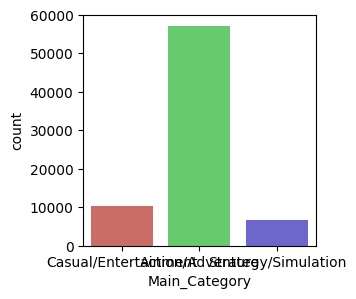

<Figure size 640x480 with 0 Axes>

In [177]:
"""
Class distribution of the target variable
"""

plt.figure(figsize = (3,3))
cleaned_dataset2['Main_Category'].value_counts()
sns.countplot(x = 'Main_Category', data = cleaned_dataset2, palette = 'hls')
plt.show()
plt.savefig('Main_Category')

In [178]:
"""
Drop the now useless columns 'Genres' and 'Categories'
"""
# Drop the original 'Genres' column
cleaned_dataset2 = cleaned_dataset2.drop(columns='Genres')
# Drop the original 'Categories' column
cleaned_dataset2 = cleaned_dataset2.drop(columns='Categories')
# Dropping any remaining NaN values just in case
cleaned_dataset2 = cleaned_dataset2.dropna()

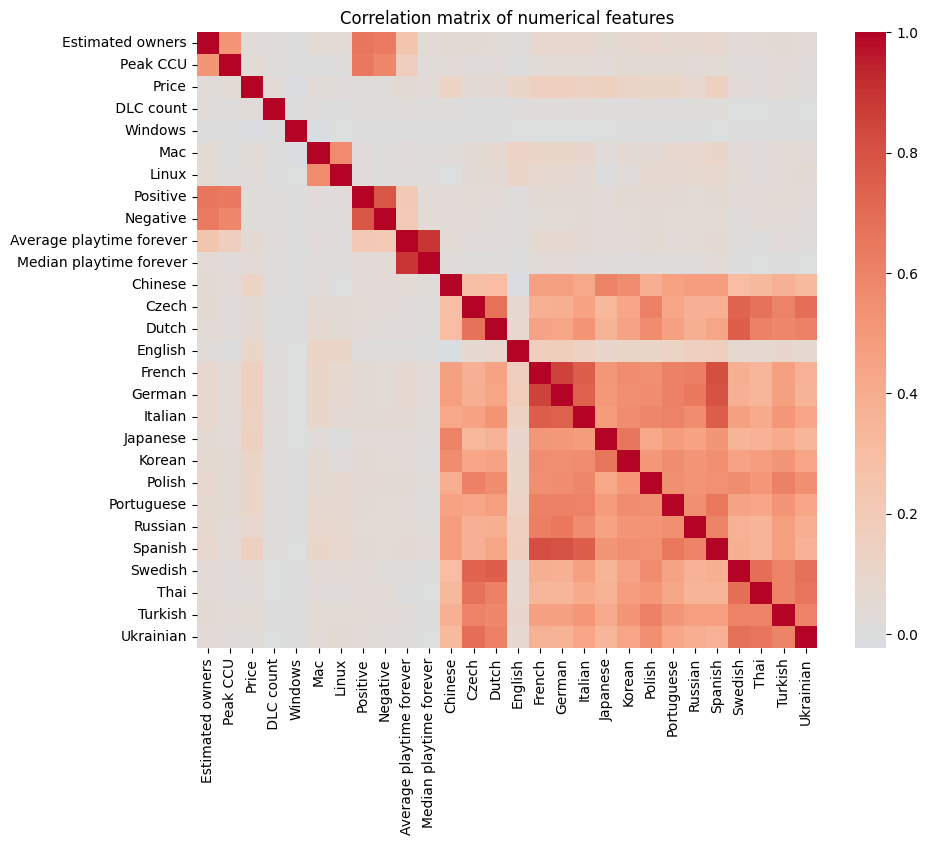

In [179]:
"""
Global overview of correlations between numerical features at this point
"""
plt.figure(figsize=(10,8))
sns.heatmap(
    cleaned_dataset2.select_dtypes(include=['int64','float64']).corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Correlation matrix of numerical features")
plt.show()


In [180]:
with open('clean_dataset.csv', 'w', encoding='utf-8') as f:
    cleaned_dataset2.to_csv(f, index=False)

##### **Data Split**

As the variable is name, in this part we are spliting the data with a rate of 80/20 for the train/test sets.

In [181]:
"""
Separate features and target variable
"""
X2 = cleaned_dataset2.drop(columns=['Main_Category'])
y2 = cleaned_dataset2['Main_Category']

In [182]:
"""
Split the dataset into training and testing sets (80% train, 20% test)
"""
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

In [183]:
"""
What we have to guess
"""
y2_train


59424        Action/Adventure
90916        Action/Adventure
39728        Action/Adventure
84604        Action/Adventure
30780        Action/Adventure
                 ...         
24732        Action/Adventure
33265    Casual/Entertainment
23060        Action/Adventure
66643        Action/Adventure
61948        Action/Adventure
Name: Main_Category, Length: 59441, dtype: object

##### **Label Encoding**

In this part we are encoding all the categoricals variables that are still not encoded

In [184]:
"""
One-Hot Encoding for Categorical Variables
"""
from sklearn.preprocessing import OneHotEncoder
x2_train_encoded = X2_train.copy()
x2_test_encoded = X2_test.copy()

# Identify categorical columns and apply One-Hot Encoding
categorical_cols = x2_train_encoded.select_dtypes(include=['object', 'category']).columns
print("Categorical columns to be encoded:", categorical_cols)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the training data
ohe_train = ohe.fit_transform(x2_train_encoded[categorical_cols])
ohe_test = ohe.transform(x2_test_encoded[categorical_cols])

# Get the new column names after One-Hot Encoding
ohe_columns = ohe.get_feature_names_out(categorical_cols)

# Create DataFrames for the One-Hot Encoded features
df_train_ohe = pd.DataFrame(ohe_train, columns=ohe_columns, index=x2_train_encoded.index)
df_test_ohe = pd.DataFrame(ohe_test, columns=ohe_columns, index=x2_test_encoded.index)

# Concatenate the One-Hot Encoded features with the original DataFrames
X2_train_encoded = pd.concat([x2_train_encoded.drop(columns=categorical_cols), df_train_ohe], axis=1)
X2_test_encoded = pd.concat([x2_test_encoded.drop(columns=categorical_cols), df_test_ohe], axis=1)

Categorical columns to be encoded: Index(['Developers', 'Publishers', 'Main_Category_2'], dtype='object')


In [185]:
"""
Check the result of the encoding
"""
print("Number of features after encoding :", X2_train_encoded.shape)
print("Original columns :", X2_train_encoded.columns.tolist())

Number of features after encoding : (59441, 2152)
Original columns : ['Estimated owners', 'Peak CCU', 'Price', ' DLC count', 'Windows', 'Mac', 'Linux', 'Positive', 'Negative', 'Average playtime forever', 'Median playtime forever', 'Chinese', 'Czech', 'Dutch', 'English', 'French', 'German', 'Italian', 'Japanese', 'Korean', 'Polish', 'Portuguese', 'Russian', 'Spanish', 'Swedish', 'Thai', 'Turkish', 'Ukrainian', 'Developers_07th Expansion', 'Developers_100 Cozy Games', 'Developers_10tons Ltd', 'Developers_16air', 'Developers_3D Realms (Apogee Software)', 'Developers_3DClouds', 'Developers_3dm_live_wallpapers', 'Developers_616 GAMES', 'Developers_727 Not Hound', 'Developers_74games', 'Developers_7miao game', 'Developers_8floor', 'Developers_90E GAMES', 'Developers_A Nostru', 'Developers_AA Mini Games Studio', 'Developers_ACQUIRE Corp.', 'Developers_AECRNIA', 'Developers_AFBIK Studio', 'Developers_AK Studio', 'Developers_ALPHY', 'Developers_AMAX Interactive', 'Developers_AMG GAMES', 'Develo

In [186]:
"""
Encode the target variable
"""
le = LabelEncoder()
y2_train = le.fit_transform(y2_train)  # encode train
y2_test = le.transform(y2_test)      # encode test

##### **Standardisation and Class Balancing**

So now, we have a lot of numericals variables that we need to be sure that there are approximatively in the same order of size. That why we are doing Standirdisation. Moreover, as you have maybe seen earlier, the distribution of the differents classes are very inequal. So, in this part we are trying to solve that issue.

In [187]:
"""
Check the columns that need to be standardized
"""
numeric_cols = cleaned_dataset2.select_dtypes(include=['int64', 'float64']).columns
print("Numérical columns to standardize :", numeric_cols)

Numérical columns to standardize : Index(['Estimated owners', 'Peak CCU', 'Price', ' DLC count', 'Windows', 'Mac',
       'Linux', 'Positive', 'Negative', 'Average playtime forever',
       'Median playtime forever', 'Chinese', 'Czech', 'Dutch', 'English',
       'French', 'German', 'Italian', 'Japanese', 'Korean', 'Polish',
       'Portuguese', 'Russian', 'Spanish', 'Swedish', 'Thai', 'Turkish',
       'Ukrainian'],
      dtype='object')


In [188]:
"""
Standardize Numerical Features
"""
scaler = StandardScaler()
X2_train_sc = X2_train_encoded.astype('float32')
X2_test_sc = X2_test_encoded.astype('float32')
X2_train_sc[numeric_cols] = scaler.fit_transform(X2_train_sc[numeric_cols])
X2_test_sc[numeric_cols] = scaler.transform(X2_test_sc[numeric_cols])

Counter({np.int64(0): 45807, np.int64(1): 45807, np.int64(2): 45807})


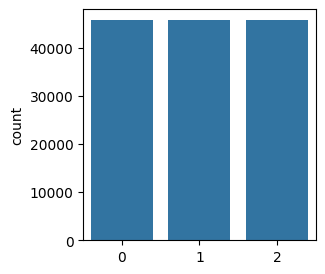

In [189]:
"""
Perform SMOTE to balance the classes in the training set
"""
X2_train_b, Y2_train_b = SMOTE(random_state=42).fit_resample(X2_train_sc, y2_train)

plt.subplots(figsize = (3,3))
sns.countplot(x = Y2_train_b)
print(Counter(Y2_train_b))

##### **Feature Scaling**

Because our dataset is very large we need to reduce it's number of features especially for KNN to be able to run.

In [190]:
"""
Reduction of dimensionality at 300 components
"""
svd = TruncatedSVD(n_components=300, random_state=42)

X2_train_red = svd.fit_transform(X2_train_b)
X2_test_red = svd.transform(X2_test_sc)


##### **Training**

In this part, we are training the 2 differents models. Please note :
- For KNN the finding of the best parameters is do in the HP tuning part.
- But for LightGBM we split it into to differents parts : The best parameters are choosen here and in the HP tuning it will find the best balances for the classes

In [191]:
"""
Train a K-Nearest Neighbors classifier
"""
knn = KNeighborsClassifier()
knn.fit(X2_train_red, Y2_train_b)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [192]:
"""
Train a LightGBM classifier
"""
# Save orginal column names before renaming
original_columns = X2_train_b.columns.tolist()

# Create a mapping of encoded feature names to original column names
feature_mapping = {f"f_{i}": original_columns[i] for i in range(len(original_columns))}

# Save it in a DataFrame for better visualization
mapping_df = pd.DataFrame({
    'Feature_Encoded': list(feature_mapping.keys()),
    'Feature_Original': list(feature_mapping.values())
})

# Display the mapping
print("=" * 70)
print("MAPPING DES FEATURES")
print("=" * 70)
print(mapping_df.to_string(index=False))
print("=" * 70)

# Save in a CSV file
mapping_df.to_csv('feature_mapping.csv', index=False)
print("\n✅ Mapping sauvegardé dans 'feature_mapping.csv'")
# Rename columns for LightGBM
X2_train_b.columns = [f"f_{i}" for i in range(X2_train_b.shape[1])]
X2_test_sc.columns = [f"f_{i}" for i in range(X2_test_sc.shape[1])]

# Ponderation by classes
counter = Counter(Y2_train_b)
total = sum(counter.values())
class_weights = {k: total / (len(counter) * v) for k, v in counter.items()}
weights = np.array([class_weights[y] for y in Y2_train_b])

# LightGBM hyperparameter grid
param_grid = [
    # Quick Baseline model
    {"num_leaves": 63, "learning_rate": 0.05, "n_estimators": 600},

    # Depper and more stable model
    {"num_leaves": 100, "learning_rate": 0.02, "n_estimators": 1200},

    # Agressive model nearly trying to overfit
    {"num_leaves": 31, "learning_rate": 0.1, "n_estimators": 400},

    # Good compromise model between the others
    {"num_leaves": 80, "learning_rate": 0.03, "n_estimators": 800},
]

best_score = -np.inf
best_params = None

for params in param_grid:
    model = LGBMClassifier(
        objective="multiclass",
        num_class=3,
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X2_train_b, Y2_train_b,
        sample_weight=weights
    )

    proba_tmp = model.predict_proba(X2_test_sc)
    y_tmp = np.argmax(proba_tmp, axis=1)

    score = f1_score(y2_test, y_tmp, average="macro")

    if score > best_score:
        best_score = score
        best_params = params

print("Best LightGBM params:", best_params)
lgb = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    **best_params,
    random_state=42,
    n_jobs=-1
)

lgb.fit(
    X2_train_b, Y2_train_b,
    sample_weight=weights
)


MAPPING DES FEATURES
Feature_Encoded                                                                                    Feature_Original
            f_0                                                                                    Estimated owners
            f_1                                                                                            Peak CCU
            f_2                                                                                               Price
            f_3                                                                                           DLC count
            f_4                                                                                             Windows
            f_5                                                                                                 Mac
            f_6                                                                                               Linux
            f_7                                    

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,600
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


##### **Predict**

This part is basically the prediction of the 2 models

In [193]:
"""
KNN Predictions
"""
Y2_pred_KNN = knn.predict(X2_test_red)

In [194]:
"""
LightGBM Predictions
"""
proba = lgb.predict_proba(X2_test_sc)
Y2_pred_lgb = np.argmax(proba, axis=1)

##### **Evaluation**

This part evaluate the first shot of the 2 algirithms without tuning

In [195]:
"""
Initial KNN Evaluation
"""
acc_KNN = accuracy_score(y2_test, Y2_pred_KNN)*100
print("KNN Accuracy: {:.3f}.".format(acc_KNN))
print("\nClassification Report")
print(classification_report(y2_test, Y2_pred_KNN))

KNN Accuracy: 71.678.

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.79      0.82     11452
           1       0.51      0.55      0.53      2054
           2       0.22      0.34      0.27      1355

    accuracy                           0.72     14861
   macro avg       0.53      0.56      0.54     14861
weighted avg       0.75      0.72      0.73     14861



In [196]:
"""
Initial LightGBM Evaluation
"""
print("LGB Accuracy :", accuracy_score(y2_test, Y2_pred_lgb))
print("\nClassification Report")
print(classification_report(y2_test, Y2_pred_lgb))

LGB Accuracy : 0.8140771145952493

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     11452
           1       0.61      0.59      0.60      2054
           2       0.59      0.23      0.33      1355

    accuracy                           0.81     14861
   macro avg       0.68      0.58      0.61     14861
weighted avg       0.80      0.81      0.80     14861



##### **Confusion Matrix**

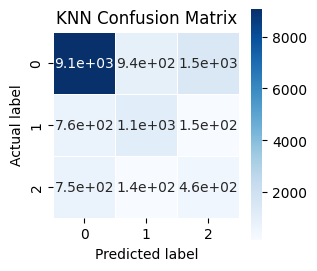

In [197]:
"""
Confusion Matrix for KNN
"""
cm_KNN = confusion_matrix(y2_test, Y2_pred_KNN)
plt.figure(figsize = (3,3))
sns.heatmap(cm_KNN, annot=True, linewidths = .5, square = True, cmap = 'Blues');
plt.xlabel('Predicted label');
plt.ylabel('Actual label');
plt.title("KNN Confusion Matrix", size = 12);

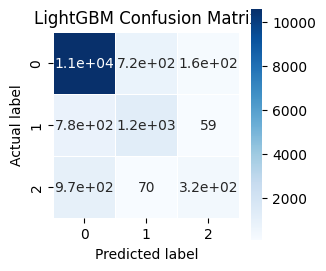

In [198]:
"""
Confusion Matrix for LightGBM
"""
cm_LGBM = confusion_matrix(y2_test, Y2_pred_lgb)
plt.figure(figsize = (3,3))
sns.heatmap(cm_LGBM, annot=True, linewidths = .5, square = True, cmap = 'Blues');
plt.xlabel('Predicted label');
plt.ylabel('Actual label');
plt.title("LightGBM Confusion Matrix", size = 12);

##### **HP Tunning**

As it's said before, here we are doing the research for the best parameters for KNN and the best balances for the classes for LightGBM. In fact, we wanted improve the guess of the minorities classes so we are doing a system of reward and punishments to avoid the fact that the algorithm only guess the biggest class and do not try to guess the others.

In [199]:
"""
Tuning KNN with RandomizedSearchCV
"""
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from numpy import random
import numpy as np

knn = KNeighborsClassifier(algorithm='kd_tree')


param_dist = {
    'n_neighbors': np.arange(5, 25),   
    'weights': ['uniform'],
    'p': [2]    
}

knn_random = RandomizedSearchCV(
    estimator = knn,
    param_distributions = param_dist,
    n_iter = 8,
    scoring = 'accuracy',
    cv = 3,
    random_state = 42,
    n_jobs = -1
)

knn_random.fit(X2_train_red, Y2_train_b)

print("Best parameters:", knn_random.best_params_)
print("Best score:", knn_random.best_score_)

# Best model
best_model = knn_random.best_estimator_
y_pred_KNN = best_model.predict(X2_test_red)


Best parameters: {'weights': 'uniform', 'p': 2, 'n_neighbors': np.int64(5)}
Best score: 0.7349022347385042


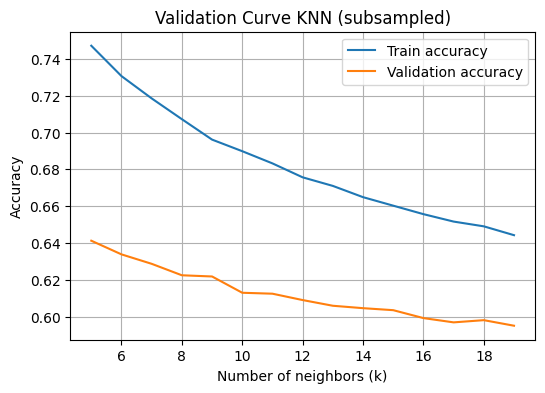

In [200]:
"""
Validation Curve KNN on a subsample of the data
"""

from sklearn.model_selection import validation_curve
from sklearn.utils import resample

# Sample (20%)
X_sub, y_sub = resample(
    X2_train_red,
    Y2_train_b,
    n_samples=int(0.2 * len(Y2_train_b)),
    random_state=42,
    stratify=Y2_train_b
)

param_range = np.arange(5, 20)

train_scores, val_scores = validation_curve(
    estimator=KNeighborsClassifier(
        weights='uniform',
        p=best_model.p,
        algorithm='auto'
    ),
    X=X_sub,
    y=y_sub,
    param_name="n_neighbors",
    param_range=param_range,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(param_range, train_mean, label="Train accuracy")
plt.plot(param_range, val_mean, label="Validation accuracy")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Validation Curve KNN (subsampled)")
plt.legend()
plt.grid(True)
plt.show()


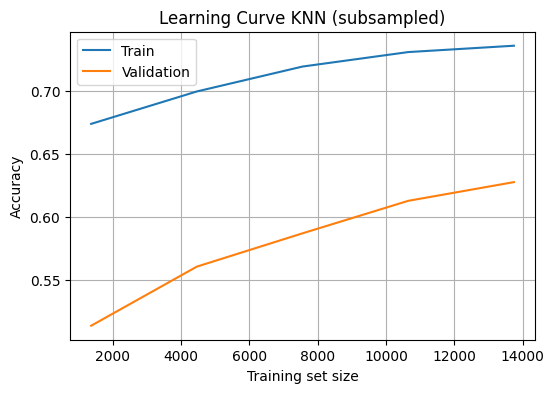

In [201]:
"""
Learning Curve KNN
"""

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_sub,
    y=y_sub,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=2,
    scoring="accuracy",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve KNN (subsampled)")
plt.legend()
plt.grid(True)
plt.show()


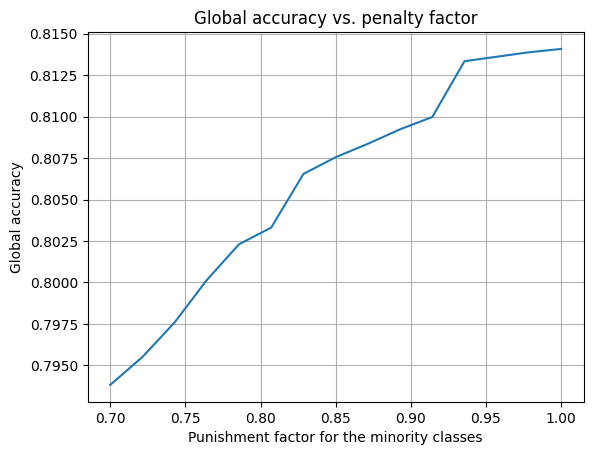

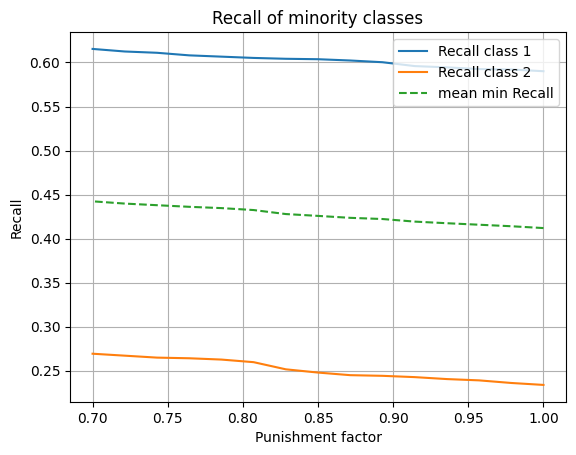

Best penalty factor: 0.7642857142857142


In [202]:
"""
Tuning for LightGBM
"""
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score

penalties = np.linspace(1.0, 0.7, 15)

accuracies = []
recall_1 = []
recall_2 = []
recall_minor_mean = []

for p in penalties:
    y_pred_adj = np.argmax(proba / [1.0, p, p], axis=1)

    acc = accuracy_score(y2_test, y_pred_adj)
    r1 = recall_score(y2_test, y_pred_adj, labels=[1], average=None)[0]
    r2 = recall_score(y2_test, y_pred_adj, labels=[2], average=None)[0]

    accuracies.append(acc)
    recall_1.append(r1)
    recall_2.append(r2)
    recall_minor_mean.append((r1 + r2) / 2)
plt.figure()
plt.plot(penalties, accuracies)
plt.xlabel("Punishment factor for the minority classes")
plt.ylabel("Global accuracy")
plt.title("Global accuracy vs. penalty factor")
plt.grid(True)
plt.show()


plt.figure()
plt.plot(penalties, recall_1, label="Recall class 1")
plt.plot(penalties, recall_2, label="Recall class 2")
plt.plot(penalties, recall_minor_mean, label="mean min Recall", linestyle="--")
plt.xlabel("Punishment factor")
plt.ylabel("Recall")
plt.title("Recall of minority classes")
plt.legend()
plt.grid(True)
plt.show()
best_idx = None
best_score = -1

for i in range(len(penalties)):
    if accuracies[i] >= 0.80:
        if recall_minor_mean[i] > best_score:
            best_score = recall_minor_mean[i]
            best_idx = i

best_penalty = penalties[best_idx]
print("Best penalty factor:", best_penalty)

##### **Re Evaluation**

In this part we are evaluating the 2 models after there respective tuning

In [203]:
"""
Training vs Testing performance (Overfitting check) KNN
"""
from sklearn.metrics import accuracy_score
from sklearn.model_selection import ValidationCurveDisplay

# Predictions on training data
y_train_pred_KNN = best_model.predict(X2_train_red)

# Accuracy comparison
train_acc = accuracy_score(Y2_train_b, y_train_pred_KNN)
test_acc = accuracy_score(y2_test, y_pred_KNN)

print("KNN Train Accuracy :", train_acc)
print("KNN Test Accuracy  :", test_acc)

KNN Train Accuracy : 0.8160688686590841
KNN Test Accuracy  : 0.7151604871812126


In [204]:
"""
Final KNN Evaluation
"""
acc_KNN = accuracy_score(y2_test, y_pred_KNN)*100
print("New KNN Accuracy: {:.3f}.".format(acc_KNN))
print("\nClassification Report")
print(classification_report(y2_test, y_pred_KNN))

New KNN Accuracy: 71.516.

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.79      0.82     11452
           1       0.51      0.55      0.53      2054
           2       0.22      0.34      0.27      1355

    accuracy                           0.72     14861
   macro avg       0.53      0.56      0.54     14861
weighted avg       0.75      0.72      0.73     14861



In [205]:
"""
Training vs Testing performance (Overfitting check) LightGBM
"""

# TRAIN
proba_train = lgb.predict_proba(X2_train_b)
y_train_pred_LGBM = np.argmax(proba_train, axis=1)

train_acc = accuracy_score(Y2_train_b, y_train_pred_LGBM)

# TEST
proba_test = lgb.predict_proba(X2_test_sc)
y_test_pred_LGBM = np.argmax(proba_test, axis=1)

test_acc = accuracy_score(y2_test, y_test_pred_LGBM)

print("LightGBM Train Accuracy :", train_acc)
print("LightGBM Test Accuracy  :", test_acc)


LightGBM Train Accuracy : 0.853792360701785
LightGBM Test Accuracy  : 0.8140771145952493


In [206]:
"""
Final LightGBM Evaluation with best penalty
"""
y_final = np.argmax(proba / [1.0, best_penalty, best_penalty], axis=1)
print("New LGB Accuracy :", accuracy_score(y2_test, y_final))
print("\nClassification Report")
print(classification_report(y2_test, y_final))

New LGB Accuracy : 0.8001480384900074

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     11452
           1       0.58      0.61      0.60      2054
           2       0.45      0.26      0.33      1355

    accuracy                           0.80     14861
   macro avg       0.63      0.59      0.60     14861
weighted avg       0.79      0.80      0.79     14861



In [207]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# KNN cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_scores = cross_val_score(best_model, X2_train_red, Y2_train_b, cv=cv, scoring='accuracy')
print("KNN 5-fold CV accuracy: {:.3f} ± {:.3f}".format(knn_scores.mean(), knn_scores.std()))

# LightGBM cross-validation
lgb_model = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    **best_params,
    random_state=42,
    n_jobs=-1
)

lgb_scores = cross_val_score(lgb_model, X2_train_b, Y2_train_b, cv=cv, scoring='accuracy')
print("LightGBM 5-fold CV accuracy: {:.3f} ± {:.3f}".format(lgb_scores.mean(), lgb_scores.std()))

# Details metrics for both models
from sklearn.metrics import classification_report

print("KNN Classification Report:")
print(classification_report(y2_test, y_pred_KNN))

print("LightGBM Classification Report:")
print(classification_report(y2_test, y_final))


KNN 5-fold CV accuracy: 0.744 ± 0.003
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14597
[LightGBM] [Info] Number of data points in the train set: 109936, number of used features: 751
[LightGBM] [Info] Start training from score -1.098621
[LightGBM] [Info] Start training from score -1.098594
[LightGBM] [Info] Start training from score -1.098621
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14614
[LightGBM] [Info] Number of data points in the train set: 109937, number of used features: 751
[LightGBM] [Info] Start training from score -1.098630
[LightGBM] [Info] Start training f

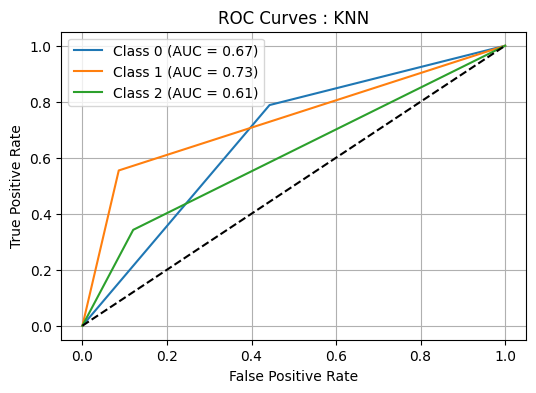

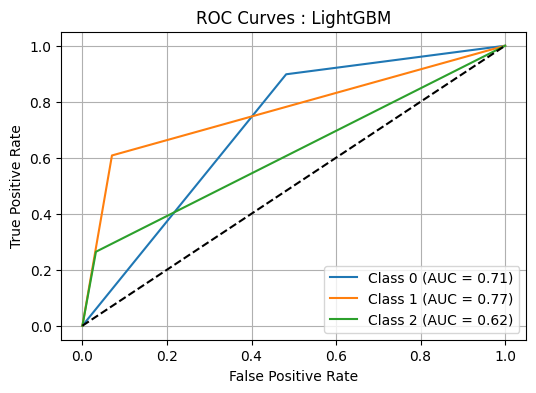

In [208]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Binarize the output for ROC curves
y_test_bin = label_binarize(y2_test, classes=[0,1,2])
y_knn_bin = label_binarize(y_pred_KNN, classes=[0,1,2])
y_lgb_bin = label_binarize(y_final, classes=[0,1,2])

# function to plot ROC curves
def plot_roc(y_true, y_score, model_name):
    n_classes = y_true.shape[1]
    plt.figure(figsize=(6,4))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label='Class {} (AUC = {:.2f})'.format(i, roc_auc))
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curves : {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

# KNN and LightGBM
plot_roc(y_test_bin, y_knn_bin, 'KNN')
plot_roc(y_test_bin, y_lgb_bin, 'LightGBM')


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.163314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17380
[LightGBM] [Info] Number of data points in the train set: 137421, number of used features: 927
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


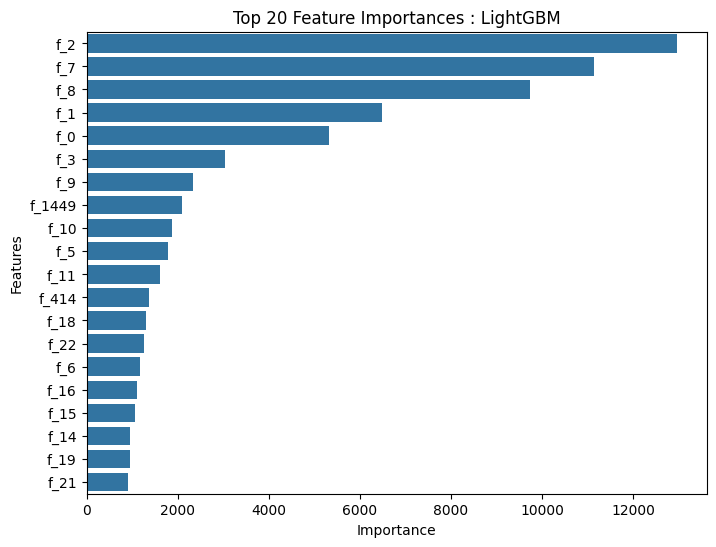

In [209]:
# Verify feature importances from LightGBM
lgb.fit(X2_train_b, Y2_train_b)
importances = lgb.feature_importances_

# Top 20 features
feat_importance = pd.Series(importances, index=X2_train_b.columns)
top20 = feat_importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x=top20.values, y=top20.index)
plt.title("Top 20 Feature Importances : LightGBM")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()



TOP 20 FEATURES WITH ORIGINAL NAMES
Feature_Encoded                  Feature_Original  Importance
            f_2                             Price       12961
            f_7                          Positive       11146
            f_8                          Negative        9731
            f_1                          Peak CCU        6496
            f_0                  Estimated owners        5313
            f_3                         DLC count        3030
            f_9          Average playtime forever        2341
         f_1449 Publishers_Independent Publishers        2101
           f_10           Median playtime forever        1883
            f_5                               Mac        1779
           f_11                           Chinese        1606
          f_414  Developers_Independent Developer        1364
           f_18                          Japanese        1301
           f_22                           Russian        1255
            f_6                  

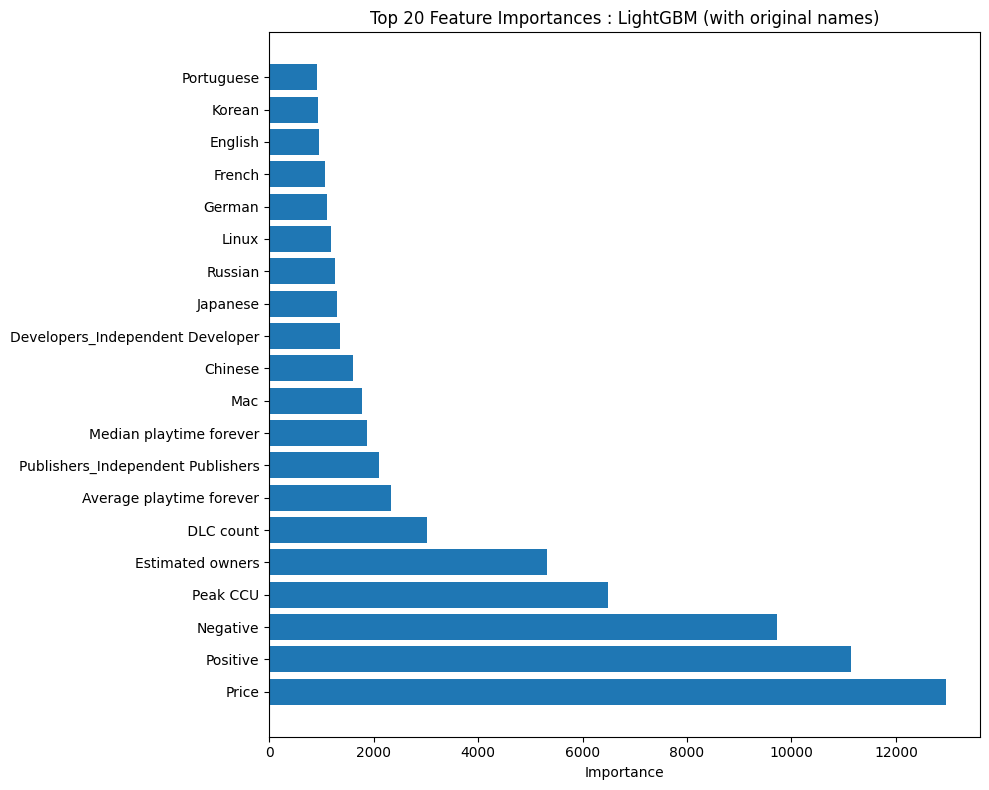


✅ Graphic save in 'feature_importance_with_names.png'


In [210]:
# Get feature importances with original names
importances = lgb.feature_importances_
feat_importance = pd.Series(importances, index=X2_train_b.columns)
top20 = feat_importance.sort_values(ascending=False).head(20)

# Create a DataFrame with original feature names
top20_with_names = pd.DataFrame({
    'Feature_Encoded': top20.index,
    'Feature_Original': [feature_mapping[f] for f in top20.index],
    'Importance': top20.values
})

print("\n" + "=" * 70)
print("TOP 20 FEATURES WITH ORIGINAL NAMES")
print("=" * 70)
print(top20_with_names.to_string(index=False))
print("=" * 70)

# Save the results to a CSV file
top20_with_names.to_csv('top20_features_with_names.csv', index=False)
print("\n✅ Top 20 features save in 'top20_features_with_names.csv'")

# Graphics with original names
plt.figure(figsize=(10, 8))
plt.barh(range(len(top20_with_names)), top20_with_names['Importance'])
plt.yticks(range(len(top20_with_names)), top20_with_names['Feature_Original'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances : LightGBM (with original names)')
plt.tight_layout()
plt.savefig('feature_importance_with_names.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Graphic save in 'feature_importance_with_names.png'")